PYTHON: /home/balaji24/skagit-met/.pixi/envs/analysis/bin/python
ENV_BIN: /home/balaji24/skagit-met/.pixi/envs/analysis/bin
PATH head: ['/home/balaji24/skagit-met/.pixi/envs/analysis/bin', '/home/balaji24/skagit-met/.pixi/envs/analysis/bin', '/bin', '/usr/local/sbin', '/usr/local/bin']
PROJ_LIB: /home/balaji24/skagit-met/.pixi/envs/analysis/share/proj
gdalbuildvrt exists? True -> /home/balaji24/skagit-met/.pixi/envs/analysis/bin/gdalbuildvrt
Clearing elevation cache at: /home/balaji24/.cache/elevation
DEM will be saved to: /home/balaji24/skagit-met/data/GIS/SkagitRiver_90mDEM.tif
Running elevation.clip ...
make: Entering directory '/home/balaji24/.cache/elevation/SRTM1'
curl -s -o spool/N47/N47W123.hgt.gz.temp https://s3.amazonaws.com/elevation-tiles-prod/skadi/N47/N47W123.hgt.gz && mv spool/N47/N47W123.hgt.gz.temp spool/N47/N47W123.hgt.gz
gunzip spool/N47/N47W123.hgt.gz 2>/dev/null || touch spool/N47/N47W123.hgt
gdal_translate -q -co TILED=YES -co COMPRESS=DEFLATE -co ZLEVEL=9 -co PRE

,OBJECTID,AREA,PERIMETER,SKAGIT_,SKAGIT_ID,GRID_CODE,Shape_Leng,Shape_Area,geometry
0,1,8.060220e+09,948300.0,2,1,1,948300.0,8.060220e+09,"POLYGON ((-120.81726 49.26101, -120.8152 49.26..."


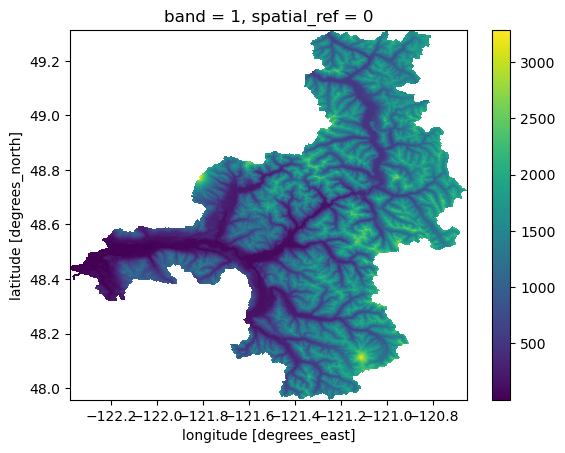

In [12]:
import sys, os, shutil
from pathlib import Path

# ================== 1) Make sure we use the pixi analysis env tools ==================
ENV_BIN  = Path(sys.executable).parent          # .../.pixi/envs/analysis/bin
ENV_ROOT = ENV_BIN.parent
PROJ_DIR = ENV_ROOT / "share" / "proj"

# Prepend env bin so elevation/make can find gdalbuildvrt, gdalwarp, etc.
os.environ["PATH"] = f"{ENV_BIN}:{os.environ.get('PATH', '')}"

# Make sure PROJ data is visible to rasterio / geopandas
if PROJ_DIR.exists():
    os.environ["PROJ_LIB"] = str(PROJ_DIR)

print("PYTHON:", sys.executable)
print("ENV_BIN:", ENV_BIN)
print("PATH head:", os.environ["PATH"].split(":")[:5])
print("PROJ_LIB:", os.environ.get("PROJ_LIB", "<not set>"))

# Quick sanity: does gdalbuildvrt exist *in this env*?
gv = ENV_BIN / "gdalbuildvrt"
print("gdalbuildvrt exists?", gv.exists(), "->", gv)

# ================== 2) IMPORTS ==================
import elevation
import geopandas as gpd
import regionmask
import rasterio
import rioxarray

%matplotlib inline

# ================== 3) Reset elevation cache (fix stale SRTM1 make stuff) ==================
cache_root = Path.home() / ".cache" / "elevation"
print("Clearing elevation cache at:", cache_root)
shutil.rmtree(cache_root, ignore_errors=True)

# ================== 4) Your original workflow ==================
# Build output path for DEM
project_root = Path(os.path.split(os.getcwd())[0])
file_path = project_root / "data" / "GIS" / "SkagitRiver_90mDEM.tif"
file_path.parent.mkdir(parents=True, exist_ok=True)
print("DEM will be saved to:", file_path)

# Download + clip DEM to Skagit-ish bounding box
print("Running elevation.clip ...")
elevation.clip(bounds=(-122.6, 47.5, -120, 49.5), output=str(file_path))

# Basin boundary
boundary_path = Path("../data/GIS/SkagitBoundary.json")
sf = gpd.read_file(str(boundary_path))
display(sf.head())

# Read DEM
dem = rioxarray.open_rasterio(
    file_path,
    masked=True,
)

# Clip DEM to Skagit polygon
poly = sf.geometry
skagit_dem = dem.rio.clip(poly)

# Plot
skagit_dem.plot()